# *ML_Model_Training*

In [1]:
from Constants import PATH
PATH=PATH
import os
os.chdir(PATH)
from utils_packeges import *

### *Import selected_features data*

In [11]:
selected_features_boruta=pd.read_csv('Data_Sets/selected_features_boruta.csv')
selected_features_boruta.head()

,total_volume,brazil,vietnam,indonesia,jordan_max_price,jordan_min_price,demand,price
0,1596040,10793,1519588,0,6,6,0,6.599075
1,1596040,10793,1519588,0,7,7,0,7.175335
2,1596040,10793,1519588,0,7,7,16,7.300575
3,2295578,5677,2274625,0,7,7,271,7.379675
4,2295578,5677,2274625,0,7,7,42,7.175335


### *Prepare data for model training*

In [12]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler,PowerTransformer,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

x=selected_features_boruta.drop("price",axis=1)
y=selected_features_boruta["price"]

X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.2)

In [13]:
from sklearn.ensemble import AdaBoostRegressor,GradientBoostingRegressor,RandomForestRegressor,BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import SGDRegressor,LinearRegression
from sklearn.neighbors import KNeighborsRegressor
import xgboost
from sklearn.model_selection import cross_val_score,cross_validate
from sklearn.metrics import mean_squared_error

In [14]:
models = {
                "RandomForestRegressor": RandomForestRegressor(),
                "XGBRFRegressor": xgboost.XGBRFRegressor(),
                "GradientBoostingRegressor":GradientBoostingRegressor(),
                "AdaBoostRegressor": AdaBoostRegressor(),
                "KNeighborsRegressor":KNeighborsRegressor(),
                "SGD_Regression": SGDRegressor(),
                "Bagging_Regression" : BaggingRegressor(DecisionTreeRegressor(), n_estimators=500),
                "XGBR_Regression": xgboost.XGBRegressor()

}

In [15]:
np.random.seed(42)
def evalua_models(x_train,y_train,models,cv):
    from tqdm import tqdm
    models_list=[]
    mean_mse_scores_list=[]

    for i in  tqdm(range(len(list(models)))):
        model=list(models.values())[i]
        neg_mse_scores = cross_val_score(model, x_train, y_train,cv=cv,scoring='neg_mean_squared_error')
        mse_scores = -neg_mse_scores
        mse_scores= np.round(mse_scores, 2)
        mean_mse_scores= round(mse_scores.mean(), 2)

        mean_mse_scores_list.append(mean_mse_scores)

        models_list.append(list(models.keys())[i])

        
    report=pd.DataFrame(list(zip(models_list,mean_mse_scores_list)),
                        columns=["model","mean_mse_scores"]).sort_values(by="mean_mse_scores",ascending=True)
    return report

np.random.seed(42)
cv_results=evalua_models(X_train,y_train,models,cv=5)

100%|██████████| 8/8 [00:18<00:00,  2.35s/it]


In [16]:
cv_results

,model,mean_mse_scores
0,RandomForestRegressor,1.200000e-01
1,XGBRFRegressor,1.200000e-01
2,GradientBoostingRegressor,1.200000e-01
6,Bagging_Regression,1.200000e-01
7,XGBR_Regression,1.300000e-01
3,AdaBoostRegressor,1.900000e-01
4,KNeighborsRegressor,1.410000e+00
5,SGD_Regression,9.957035e+42


In [17]:
best_model=[list(models.values())[i] for i in range(len(models)) if cv_results["model"].values[1]==list(models.keys())[i]][0]

best model :. RandomForestRegressor
CV fold MSEs: [0.1  0.1  0.2  0.09 0.12]
CV mean MSE:, 0.12
CV std dev MSE:, 0.04
Standard Error (SE), 0.04
Mean CV MSE = 0.12 ± 0.04 (95% CI: [0.08, 0.16])
Test set MSE: 0.16
Test set RMSE: 0.4
---> :
✅ Test MSE is within CV variability—model generalizes well!


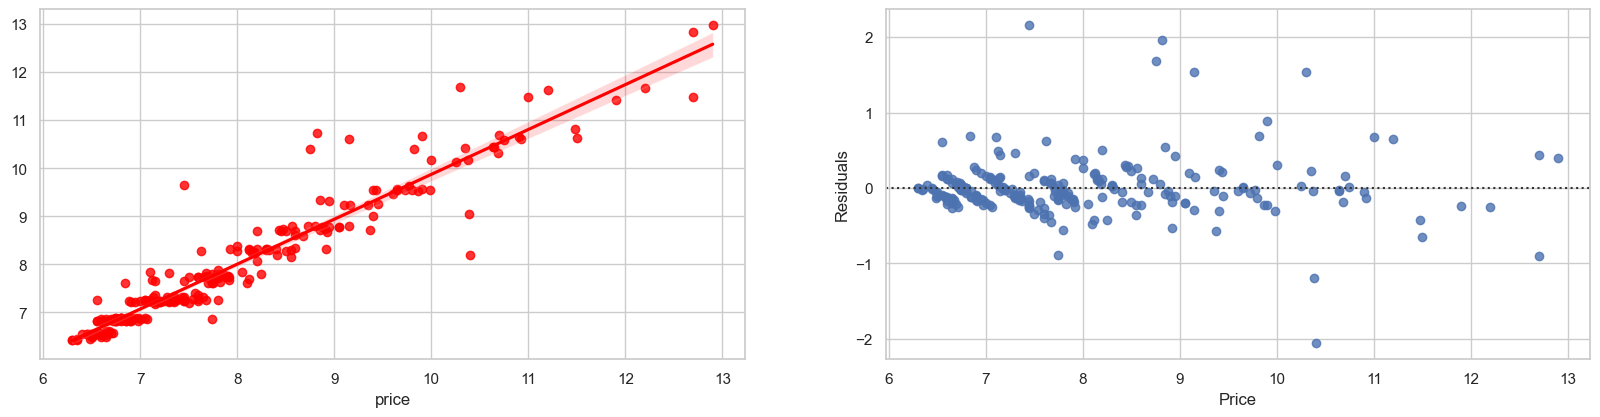

Feature importance:
       Feature Name  Feature Importance
4  jordan_max_price            0.694847
5  jordan_min_price            0.275005
6            demand            0.008789
3         indonesia            0.006383
2           vietnam            0.005501
0      total_volume            0.005289
1            brazil            0.004186


In [18]:
def perform_best_model(x_train,y_train,x_val,y_val,model):
    print("best model :.", cv_results["model"].values[0])
    np.random.seed(42)
    cv=5

    neg_mse_scores = cross_val_score(model, X_train, y_train,cv=cv,scoring='neg_mean_squared_error')
    mse_scores = -neg_mse_scores
    mse_scores= np.round(mse_scores, 2)
    mean_mse_scores= round(mse_scores.mean(), 2)
    std_mse_scores= round(mse_scores.std(), 2)
    Standard_Error_SE=std_mse_scores/np.sqrt(cv)
    ci_lower = mean_mse_scores - 2* Standard_Error_SE
    ci_upper = mean_mse_scores + 2* Standard_Error_SE  
    ci=[ci_lower, ci_upper]

    print("CV fold MSEs:", mse_scores)
    print(f"CV mean MSE:, {mean_mse_scores:.2f}")
    print(f"CV std dev MSE:, {std_mse_scores:.2f}")
    print(f"Standard Error (SE), {1.96*Standard_Error_SE:.2f}")
    print(f"Mean CV MSE = {mean_mse_scores:.2f} ± {1.96*Standard_Error_SE:.2f} "
        f"(95% CI: [{ci_lower:.2f}, {ci_upper:.2f}])")

    print("==================================")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    final_mse = mean_squared_error(y_val, y_pred)
    final_rmse = np.sqrt(final_mse)

    print("Test set MSE:", round(final_mse, 2))
    print("Test set RMSE:", round(final_rmse, 2))
    print("---> :")
    threshold = mean_mse_scores + std_mse_scores
    if final_mse <= threshold:
        print("✅ Test MSE is within CV variability—model generalizes well!")
    else:
        print("⚠️ Test MSE exceeds CV range—review for overfitting or data mismatch.")

    plt.subplot(221)
    sns.regplot(x=y_val,y=y_pred,ci=95,color ='red')

    plt.subplot(222)
    sns.residplot(x=y_val,y=y_pred)
    plt.xlabel("Price")
    plt.ylabel("Residuals")
    plt.show();

    importance=pd.concat([pd.DataFrame(X_train.columns.tolist(),columns=["Feature Name"]),
            pd.DataFrame(list(model.feature_importances_),columns=["Feature Importance"])],axis=1)
    importance=importance.sort_values(by="Feature Importance",ascending=False)

    print(f"Feature importance:")
    print(f"{importance}")

    return   x_train,y_train,x_val,y_val,model,importance


x_train,y_train,x_val,y_val,model,importance=perform_best_model(X_train,y_train,X_val,y_val,best_model)

SHAP values shape: (972, 7)
Base value (baseline prediction): 8.018699645996094
The base value (expected value) represents what the model would predict if we didn't know anything about the features.
it's essentially the average prediction across all training samples.
-- Each dot represents a sample.
-- the color represents feature value.
-- the position on x-axis shows the SHAP value (impact on prediction).
-- This tells us not just which features are important, but also how their values affect predictions.
SHAP summary plot:


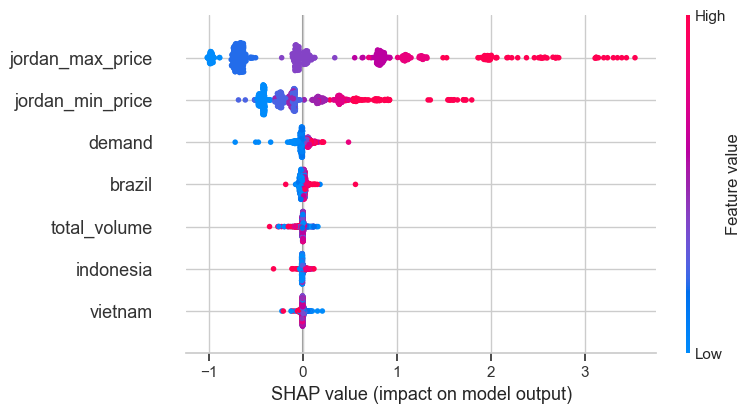

Waterfall plot:
the waterfall plot breaks down the prediction for this specific sample,showing how each feature contributed topushing the prediction from the baseline (expected value) to the final predicted value.the f(x) function is the final prediction for this sample-sample_idx


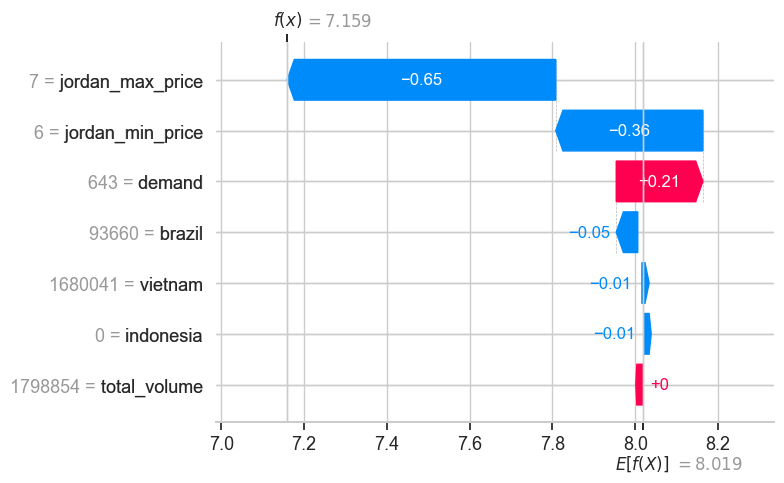

Force plot:


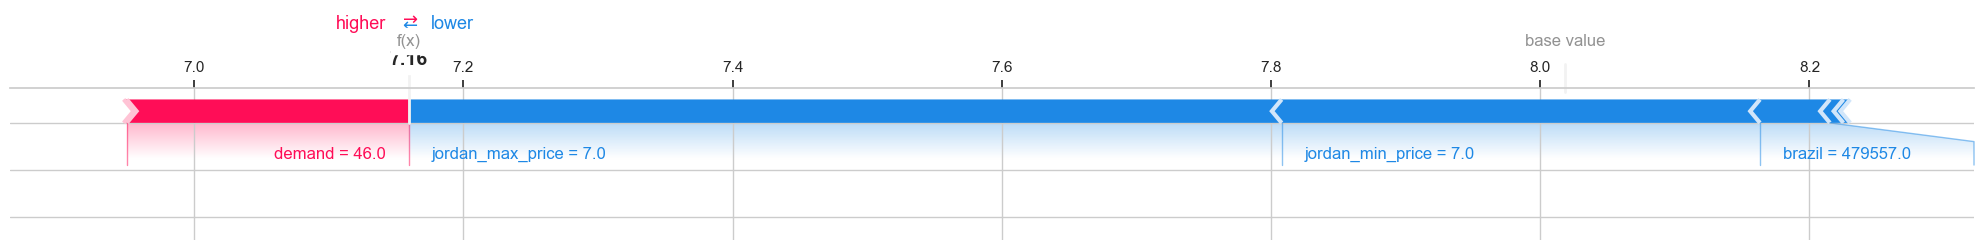

In [20]:
import shap
np.random.seed(42)
def shap_model(model,X_train,sample_idx=None):
    import shap

    explainer = shap.TreeExplainer(model)
    # Calculate SHAP values for all training data - this gives us the baseline
    shap_values = explainer(X_train)

    print(f"SHAP values shape: {shap_values.values.shape}")
    print(f"Base value (baseline prediction): {np.round(explainer.expected_value,4)}")

    print("The base value (expected value) represents what the model would predict if we didn't know anything about the features.\nit's essentially the average prediction across all training samples.")
    print("-- Each dot represents a sample.\n-- the color represents feature value.\n-- the position on x-axis shows the SHAP value (impact on prediction).\n-- This tells us not just which features are important, but also how their values affect predictions.")
    shap_values = explainer(X_train)
    print("SHAP summary plot:")
    plt.figure(figsize=(30, 7))
    shap.summary_plot(shap_values, X_train, show=False)
    plt.tight_layout()
    plt.show();

    if sample_idx is not None:
        sample_idx = sample_idx
        sample = X_val[sample_idx:sample_idx+1]

        prediction = model.predict(sample)[0]

        # Calculate SHAP values for this single sample
        shap_values_sample = explainer(X_train)

        # Waterfall plot shows how we got from baseline to final prediction
        print("Waterfall plot:")
        print("the waterfall plot breaks down the prediction for this specific sample," \
        "showing how each feature contributed to" \
        "pushing the prediction from the baseline (expected value) to the final predicted value."\
        "the f(x) function is the final prediction for this sample-sample_idx")
        plt.figure(figsize=(20, 8))
        shap.plots.waterfall(shap_values_sample[0], show=False)
        plt.tight_layout()
        plt.show();
        # # Force plot is an alternative way to visualize the same information
        print("Force plot:")
        shap.force_plot(explainer.expected_value, shap_values_sample.values[0], sample.iloc[0], matplotlib=True, show=False)
        plt.tight_layout()
        plt.show();
        base_value=f"{np.round(explainer.expected_value,4)}"

        return shap_values, base_value,prediction,shap_values_sample

shap_values, base_value,prediction,shap_values_sample=shap_model(best_model,X_train,10)  
